In [ ]:
Objective:
The objective of this assessment is to evaluate your understanding and ability to apply clustering
techniques to a real-world dataset.
Dataset
Use the Iris dataset available in the sklearn library.
Key components to be fulfilled :
Loading and Preprocessing (1 mark)
● Load the Iris dataset from sklearn.
● Drop the species column since this is a clustering problem.
Clustering Algorithm Implementation (8 marks): Implement the following two clustering algorithms:
1. KMeans Clustering (4 marks) :
● Provide a brief description of how KMeans clustering works.
● Explain why KMeans clustering might be suitable for the Iris dataset.
● Apply KMeans clustering to the preprocessed Iris dataset and visualize the clusters.
2. Hierarchical Clustering (4 marks):
● Provide a brief description of how Hierarchical clustering works.
● Explain why Hierarchical clustering might be suitable for the Iris dataset.
● Apply Hierarchical clustering to the preprocessed Iris dataset and visualize the clusters.

Timely Submission (1 mark)
Submission Guidelines Provide your code in a Jupyter Notebook format and submit the GitHub link here.
Ensure your explanations and answers are clear and concise.
Total Score: 10

# Loading and Preprocessing (1 mark)
# `   ● Load the Iris dataset from sklearn.
#    ● Drop the species column since this is a clustering problem.

In [1]:
import pandas as pd
import numpy as np
from sklearn.datasets import load_iris

In [ ]:
# Import required libraries
import pandas as pd
import numpy as np
from sklearn.datasets import load_iris
import matplotlib.pyplot as plt
import seaborn as sns


In [3]:
iris = load_iris()

df = pd.DataFrame(data=iris.data, columns=iris.feature_names)
df['species'] = iris.target

df.head()


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [4]:
x = df.drop(columns=['species']) 

Clustering is unsupervised, so labels (species) must not be used.

In [5]:
x.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


# 1. KMeans Clustering (4 marks) :
# ● Provide a brief description of how KMeans clustering works.
# ● Explain why KMeans clustering might be suitable for the Iris dataset.
# ● Apply KMeans clustering to the preprocessed Iris dataset and visualize the clusters.

# How K-Means Works: 

    K-Means is an unsupervised clustering algorithm that partitions data into K clusters.

# It works by:

    Randomly selecting K centroids

    Assigning each point to the nearest centroid

    Recomputing new centroids

    Repeating the process until cluster assignments stabilize

    Uses Euclidean distance to measure similarity.


# Why K-Means is Suitable for Iris Dataset

    Iris dataset has well-separated clusters (3 species).

    Features are continuous numerical values ,  perfect for K-Means.

    The dataset is small and clean ,  fast convergence.

In [6]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, random_state=42)
clusters_kmeans = kmeans.fit_predict(x)

In [7]:
df['kmeans_cluster'] = clusters_kmeans

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

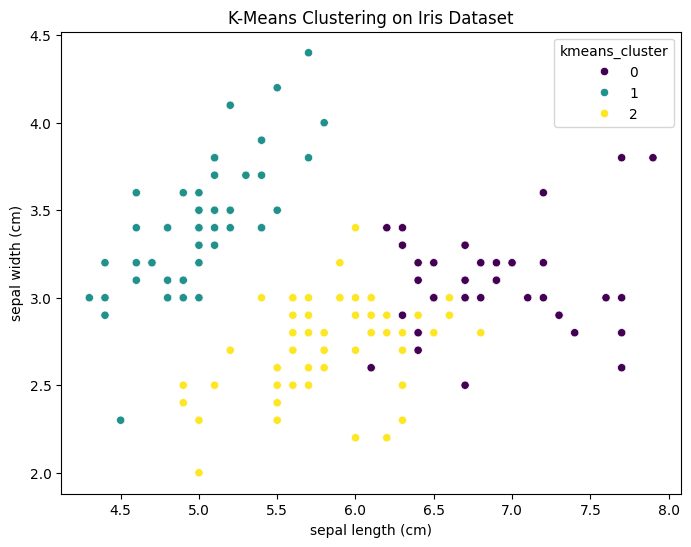

In [10]:
plt.figure(figsize=(8,6))
sns.scatterplot(
    x=df['sepal length (cm)'],
    y=df['sepal width (cm)'],
    hue=df['kmeans_cluster'],
    palette='viridis'
)
plt.title("K-Means Clustering on Iris Dataset")
plt.show()

# 2. Hierarchical Clustering (4 marks):
# ● Provide a brief description of how Hierarchical clustering works.
# ● Explain why Hierarchical clustering might be suitable for the Iris dataset.
# ● Apply Hierarchical clustering to the preprocessed Iris dataset and visualize the clusters.

# How Hierarchical Clustering Works:

    Hierarchical clustering builds clusters step-by-step using either:


# Agglomerative (Bottom-Up)

    Each data point starts as its own cluster

    The two closest clusters are merged

    Repeated until all points belong to one big cluster


# Divisive (Top-Down)

    Start with one large cluster

    Split into smaller clusters

    The output is visualized using a dendrogram.



# Why Hierarchical Clustering is Suitable for Iris Dataset

    Iris dataset has clear cluster boundaries.

    Good for visualizing relationships using a dendrogram.

    Performs well for small datasets.

In [14]:
from sklearn.cluster import AgglomerativeClustering

hier = AgglomerativeClustering(n_clusters=3)
clusters_hier = hier.fit_predict(x)
clusters_hier

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 2, 2, 2, 2, 0, 2, 2, 2,
       2, 2, 2, 0, 0, 2, 2, 2, 2, 0, 2, 0, 2, 0, 2, 2, 0, 0, 2, 2, 2, 2,
       2, 0, 0, 2, 2, 2, 0, 2, 2, 2, 0, 2, 2, 2, 0, 2, 2, 0])

In [15]:
df['hier_cluster'] = clusters_hier

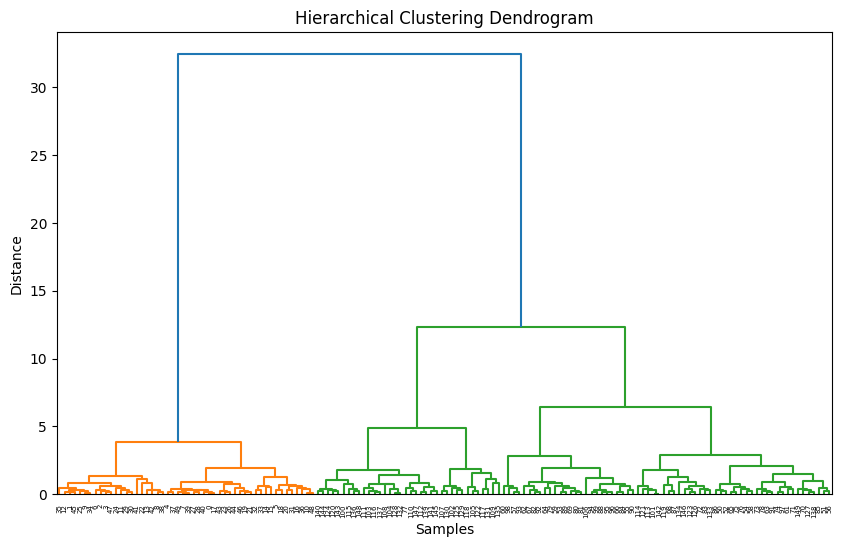

In [16]:
from scipy.cluster.hierarchy import dendrogram, linkage

plt.figure(figsize=(10,6))
linkage_matrix = linkage(x, method='ward')
dendrogram(linkage_matrix)
plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Samples")
plt.ylabel("Distance")
plt.show()


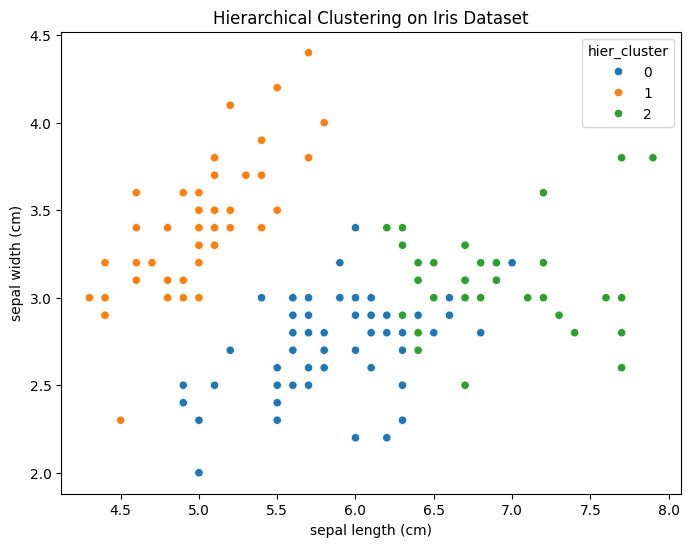

In [17]:
plt.figure(figsize=(8,6))
sns.scatterplot(
    x=df['sepal length (cm)'],
    y=df['sepal width (cm)'],
    hue=df['hier_cluster'],
    palette='tab10'
)
plt.title("Hierarchical Clustering on Iris Dataset")
plt.show()